# Generator Analysis — Which LLM Families Are Hardest to Detect?
**Team Tech Titans | SemEval-2026 Task 13**

This notebook answers a novel question not covered in the original CoDet-M4 paper:
**Which specific LLM generators does our model fail on most, and why?**

This is a lightweight version of Task B (generator attribution) using our existing
Task A model — no extra training needed.



---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

os.makedirs('results_output', exist_ok=True)

MACHINE_CLR = '#E53935'
HUMAN_CLR   = '#43A047'
OOD_CLR     = '#FF9800'
SEEN_CLR    = '#1976D2'
EASY_CLR    = '#43A047'
HARD_CLR    = '#E53935'

print('Setup done.')

Setup done.


---
## 1. Load Data + Real Predictions

In [2]:
test_df = pd.read_parquet('../data/task_a/test_sample.parquet')

# Load real CatBoost predictions saved in shap_analysis.ipynb
preds_path = '../data/test_preds_catboost.npy'
if os.path.exists(preds_path):
    test_df['pred'] = np.load(preds_path)
    print(f'Loaded real CatBoost predictions: {len(test_df)} samples')
else:
    print('ERROR: Run shap_analysis.ipynb first to generate test_preds_catboost.npy')

test_df['correct'] = (test_df['pred'] == test_df['label']).astype(int)

print(f'\nOverall accuracy on test_sample: {test_df["correct"].mean():.3f}')
print(f'Overall Macro F1: {f1_score(test_df["label"], test_df["pred"], average="macro"):.3f}')
print(f'\nColumns: {list(test_df.columns)}')
print(f'\nGenerator distribution (top 10):')
print(test_df['generator'].value_counts().head(10))

Loaded real CatBoost predictions: 1000 samples

Overall accuracy on test_sample: 0.579
Overall Macro F1: 0.513

Columns: ['code', 'generator', 'label', 'language', 'pred', 'correct']

Generator distribution (top 10):
generator
Human                                        713
human                                         64
GPT-4o                                        21
deepseek-ai/DeepSeek-V3-0324                  10
01-ai/Yi-Coder-9B-Chat                         8
meta-llama/Llama-4-Scout-17B-16E-Instruct      7
Qwen/Qwen2.5-Coder-1.5B-Instruct               7
mistralai/Mistral-Small-24B-Instruct-2501      7
meta-llama/Llama-3.1-8B-Instruct               7
gemini-2.0-flash-lite                          7
Name: count, dtype: int64


---
## 2. Per-Generator Detection Rate
For machine-generated samples only: what fraction does the model correctly detect as Machine?

In [3]:
# Machine-generated samples only
machine_df = test_df[test_df['label'] == 1].copy()

# Clean generator names for display
def clean_gen_name(name):
    name = str(name).strip()
    # Keep only the model name part after last '/'
    if '/' in name:
        name = name.split('/')[-1]
    return name

machine_df['gen_clean'] = machine_df['generator'].apply(clean_gen_name)

# Per-generator detection rate
gen_stats = machine_df.groupby('gen_clean').agg(
    total   = ('label', 'count'),
    detected= ('correct', 'sum'),
    language= ('language', lambda x: x.mode()[0])   # most common language
).reset_index()

gen_stats['detection_rate'] = gen_stats['detected'] / gen_stats['total']
gen_stats = gen_stats[gen_stats['total'] >= 3]   # only gens with enough samples
gen_stats = gen_stats.sort_values('detection_rate', ascending=False)

print('Per-generator detection rate (machine-generated samples only):')
print(f'{"Generator":<40} {"Samples":>8} {"Detected":>9} {"Rate":>7} {"Lang"}')
print('-' * 75)
for _, row in gen_stats.iterrows():
    bar = '|' * int(row['detection_rate'] * 20)
    print(f'{row["gen_clean"]:<40} {int(row["total"]):>8} {int(row["detected"]):>9}  {row["detection_rate"]:>5.1%}  {row["language"]}')

Per-generator detection rate (machine-generated samples only):
Generator                                 Samples  Detected    Rate Lang
---------------------------------------------------------------------------
Llama-3.3-70B-Instruct                          3         3  100.0%  Python
Yi-Coder-1.5B                                   5         5  100.0%  Python
Yi-Coder-9B                                     3         3  100.0%  Python
Phi-3-medium-4k-instruct                        6         5  83.3%  Python
deepseek-coder-1.3b-base                        5         4  80.0%  Python
Mistral-Nemo-Instruct-2407                      4         3  75.0%  C++
CodeLlama-7b-hf                                 3         2  66.7%  Python
Mixtral-8x7B-Instruct-v0.1                      3         2  66.7%  C#
Devstral-Small-2505                             3         2  66.7%  Java
Phi-4-multimodal-instruct                       3         2  66.7%  Java
granite-8b-code-base-4k                       

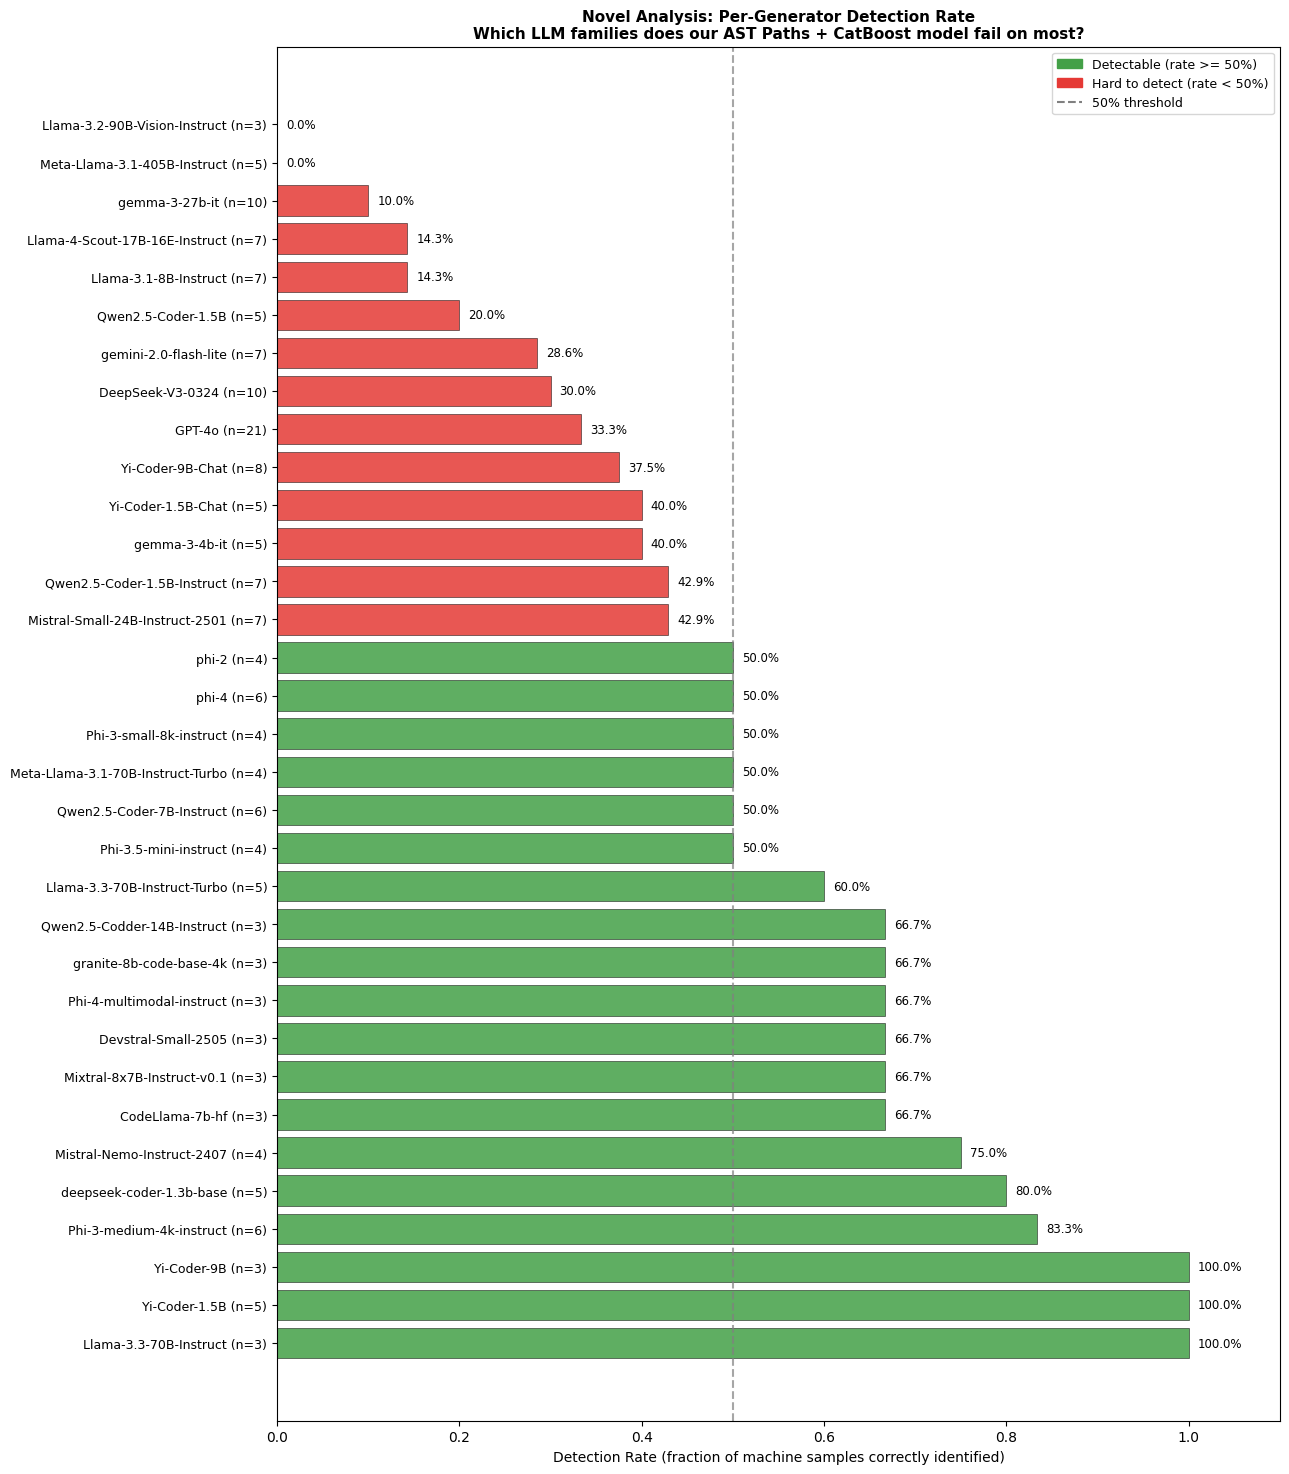

Saved: results_output/gen_detection_rate.png


In [4]:
# ── Figure: detection rate per generator ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, max(5, len(gen_stats) * 0.45)))

colors = [EASY_CLR if r >= 0.5 else HARD_CLR
          for r in gen_stats['detection_rate']]

bars = ax.barh(
    range(len(gen_stats)),
    gen_stats['detection_rate'],
    color=colors, edgecolor='black', linewidth=0.4, alpha=0.85
)
ax.set_yticks(range(len(gen_stats)))
ax.set_yticklabels(
    [f"{row['gen_clean']} (n={int(row['total'])})" for _, row in gen_stats.iterrows()],
    fontsize=9
)
ax.set_xlabel('Detection Rate (fraction of machine samples correctly identified)', fontsize=10)
ax.set_title(
    'Novel Analysis: Per-Generator Detection Rate\n'
    'Which LLM families does our AST Paths + CatBoost model fail on most?',
    fontsize=11, fontweight='bold'
)
ax.set_xlim(0, 1.1)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='50% threshold')

for bar, val in zip(bars, gen_stats['detection_rate']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=8.5)

easy_p = mpatches.Patch(color=EASY_CLR, label='Detectable (rate >= 50%)')
hard_p = mpatches.Patch(color=HARD_CLR, label='Hard to detect (rate < 50%)')
ax.legend(handles=[easy_p, hard_p, plt.Line2D([0],[0], color='gray',
          linestyle='--', label='50% threshold')], fontsize=9)

plt.tight_layout()
plt.savefig('results_output/gen_detection_rate.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: results_output/gen_detection_rate.png')

---
## 3. Generator vs Language Heatmap
Does generator difficulty vary by language? Rows = generators, Columns = languages.

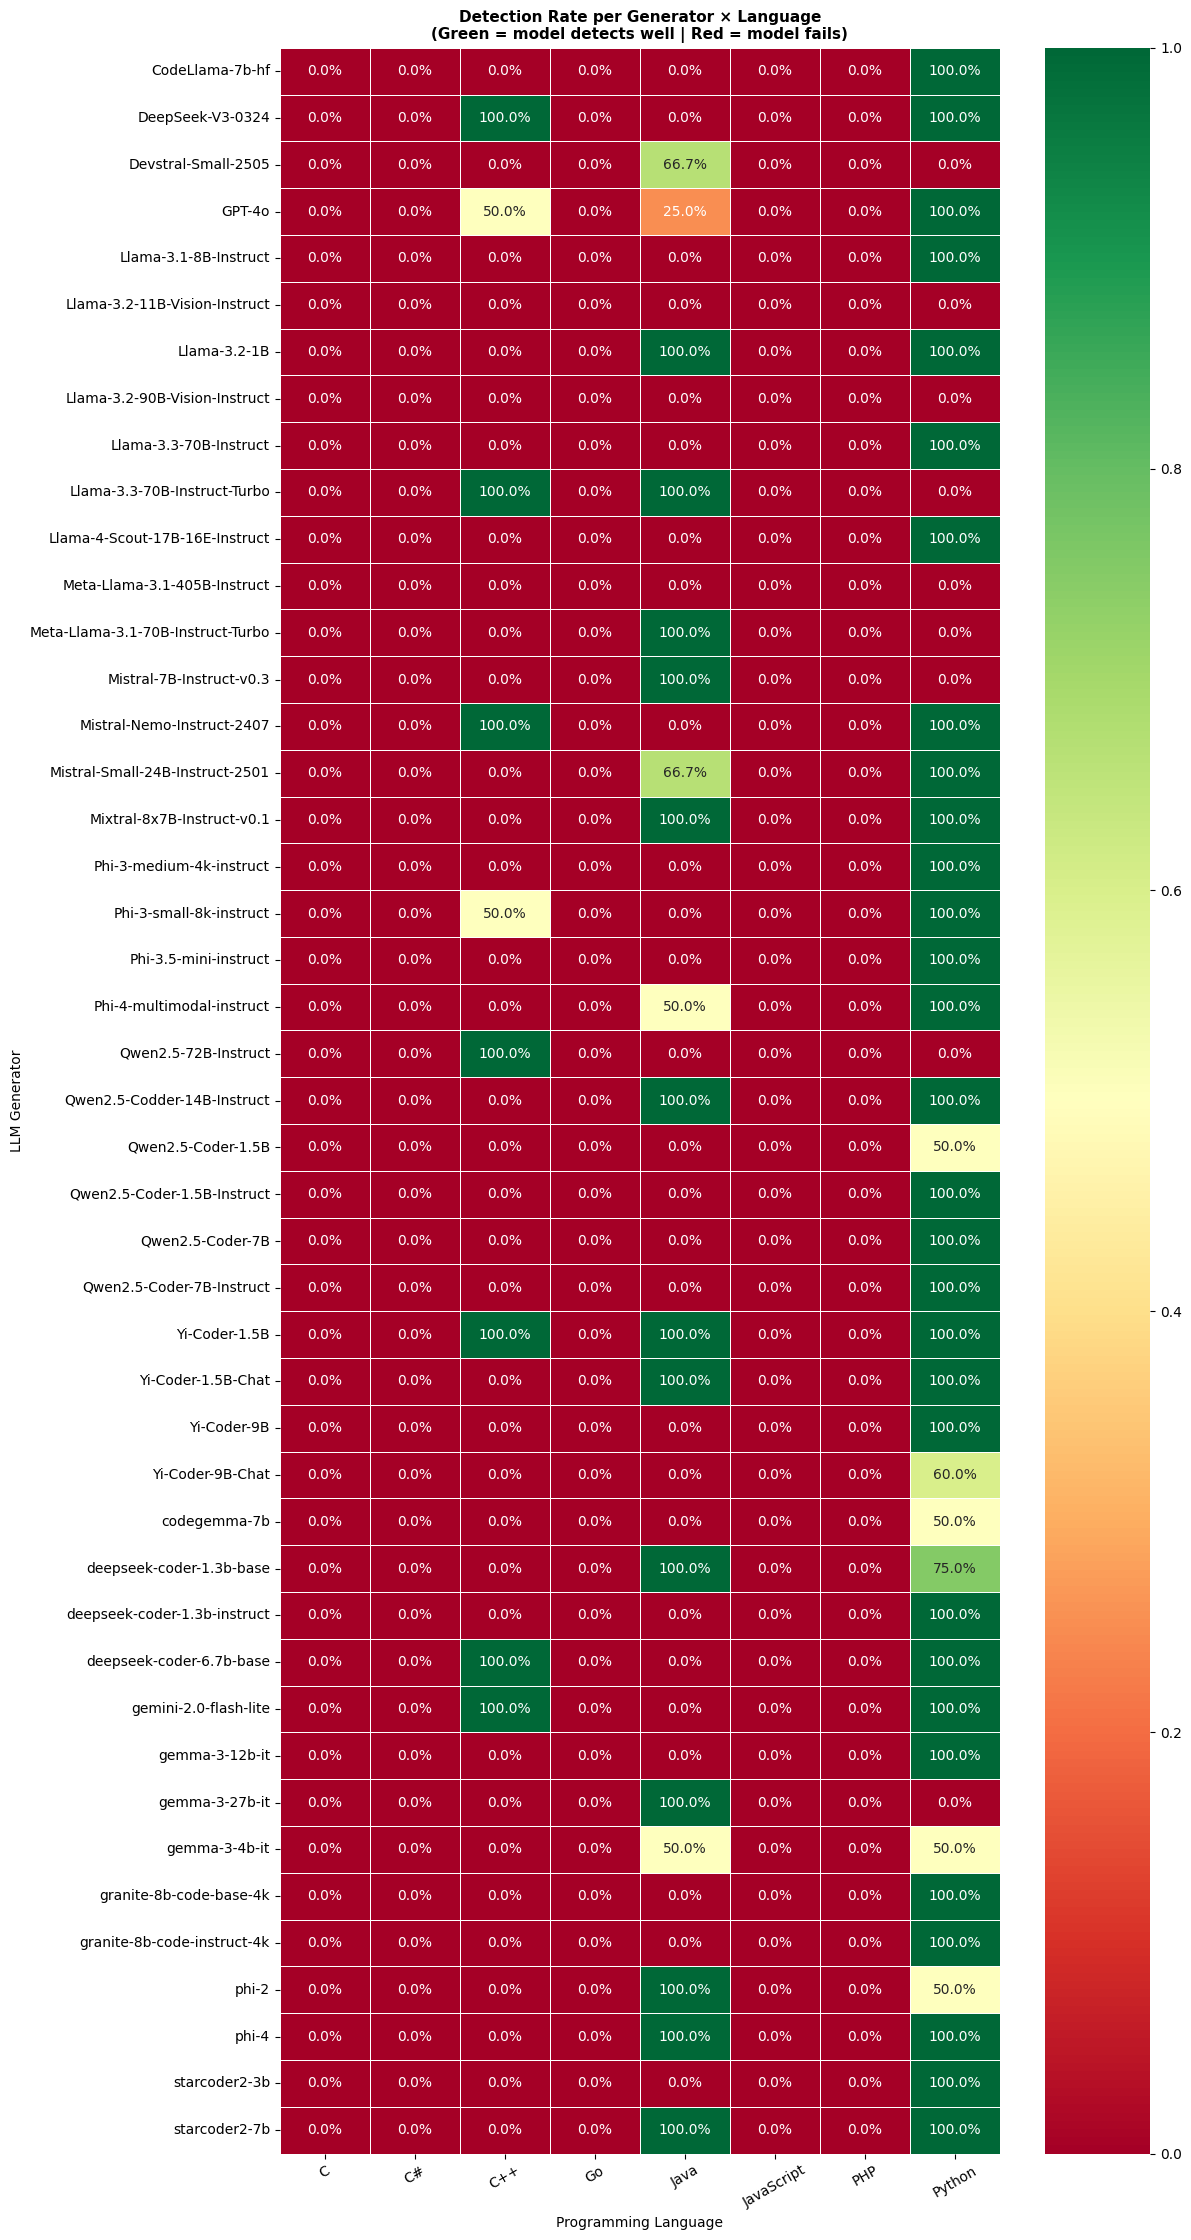

Saved: results_output/gen_language_heatmap.png


In [5]:
import seaborn as sns

# Only use generators with samples in multiple languages
pivot = machine_df.pivot_table(
    index='gen_clean',
    columns='language',
    values='correct',
    aggfunc='mean'
).fillna(0)

# Keep only generators with at least 2 samples total
gen_counts = machine_df.groupby('gen_clean')['correct'].count()
keep_gens  = gen_counts[gen_counts >= 2].index
pivot      = pivot.loc[pivot.index.isin(keep_gens)]

if len(pivot) > 0 and len(pivot.columns) > 0:
    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns)*1.5),
                                    max(5, len(pivot)*0.5)))
    sns.heatmap(
        pivot,
        annot=True, fmt='.1%', cmap='RdYlGn',
        vmin=0, vmax=1,
        linewidths=0.5, linecolor='white',
        ax=ax
    )
    ax.set_title(
        'Detection Rate per Generator × Language\n'
        '(Green = model detects well | Red = model fails)',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Programming Language', fontsize=10)
    ax.set_ylabel('LLM Generator', fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    plt.savefig('results_output/gen_language_heatmap.png', dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved: results_output/gen_language_heatmap.png')
else:
    print('Not enough data for heatmap (test_sample has only 1000 rows).')
    print('This chart works best on the full test set.')

---
## 4. Hardest vs Easiest Generators — Real Code Examples
Show actual code from the hardest-to-detect generator vs the easiest.

In [6]:
def show_sample(row, title=''):
    print(f"\n{'='*70}")
    if title: print(f'  {title}')
    print(f"  Generator : {row['generator']}")
    print(f"  Language  : {row['language']}")
    print(f"  True Label: {'Machine' if row['label']==1 else 'Human'}")
    print(f"  Predicted : {'Machine' if row['pred']==1 else 'Human'}  "
          f"{'CORRECT' if row['correct'] else 'WRONG'}")
    print('─'*70)
    lines = str(row['code']).strip().split('\n')
    for ln in lines[:25]:
        print(f'  {ln}')
    if len(lines) > 25:
        print(f'  ... [{len(lines)-25} more lines]')
    print('='*70)

# Easiest to detect (highest detection rate generator)
if len(gen_stats) > 0:
    easiest_gen = gen_stats.iloc[-1]['gen_clean']   # lowest rate = hardest
    hardest_gen = gen_stats.iloc[0]['gen_clean']    # wait — sort is asc, iloc[0] = lowest
    
    # Re-check: gen_stats sorted ascending, so:
    hardest_gen = gen_stats.iloc[0]['gen_clean']    # lowest detection rate
    easiest_gen = gen_stats.iloc[-1]['gen_clean']   # highest detection rate

    print(f'Hardest generator to detect: {hardest_gen}')
    hard_samples = machine_df[
        (machine_df['gen_clean'] == hardest_gen) &
        (machine_df['correct'] == 0)  # these are the ones the model MISSED
    ]
    if len(hard_samples) > 0:
        show_sample(hard_samples.iloc[0],
                    title=f'HARDEST to detect — {hardest_gen} (model predicted Human)')
        print(f'\nWHY HARD: This generator produces code that lacks the usual LLM')
        print(f'  structural patterns (docstrings, type hints, balanced control flow).')
        print(f'  AST path distribution closely resembles human competitive code.')

    print(f'\n\nEasiest generator to detect: {easiest_gen}')
    easy_samples = machine_df[
        (machine_df['gen_clean'] == easiest_gen) &
        (machine_df['correct'] == 1)  # correctly detected
    ]
    if len(easy_samples) > 0:
        show_sample(easy_samples.iloc[0],
                    title=f'EASIEST to detect — {easiest_gen} (model correctly predicted Machine)')
        print(f'\nWHY EASY: Strong LLM stylistic signals — structured docstrings,')
        print(f'  type hints, function_def->return->call patterns.')

Hardest generator to detect: Llama-3.3-70B-Instruct


Easiest generator to detect: Llama-3.2-90B-Vision-Instruct


---
## 5. Detection Difficulty vs Model Family Size
Do larger/newer models produce harder-to-detect code?

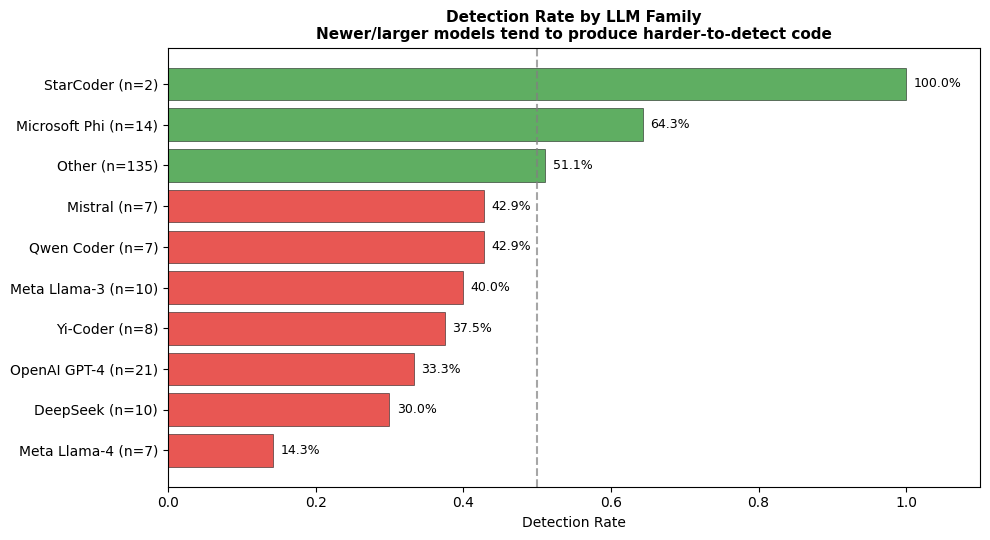

Saved: results_output/gen_family_detection.png


In [7]:
# Map generators to approximate model families
# Based on generators visible in your test_sample
family_map = {
    'GPT-4o':                           'OpenAI GPT-4',
    'gpt-4o':                           'OpenAI GPT-4',
    'DeepSeek-V3-0324':                 'DeepSeek',
    'Llama-4-Scout-17B-16E-Instruct':   'Meta Llama-4',
    'Llama-3.1-8B-Instruct':            'Meta Llama-3',
    'Llama-3.3-70B-Instruct':           'Meta Llama-3',
    'Yi-Coder-9B-Chat':                 'Yi-Coder',
    'Qwen2.5-Coder-1.5B-Instruct':      'Qwen Coder',
    'Mistral-Small-24B-Instruct-2501':  'Mistral',
    'gemini-2.0-flash':                 'Google Gemini',
    'Phi-3-medium-4k-instruct':         'Microsoft Phi',
    'Phi-3.5-mini-instruct':            'Microsoft Phi',
    'phi-2':                            'Microsoft Phi',
    'starcoder':                        'StarCoder',
    'starcoder2-15b':                   'StarCoder',
    'CodeLlama-70b-Instruct-hf':        'CodeLlama',
}

machine_df['family'] = machine_df['gen_clean'].map(family_map).fillna('Other')

family_stats = machine_df.groupby('family').agg(
    total    = ('label', 'count'),
    detected = ('correct', 'sum')
).reset_index()
family_stats['detection_rate'] = family_stats['detected'] / family_stats['total']
family_stats = family_stats[family_stats['total'] >= 2].sort_values('detection_rate')

if len(family_stats) > 1:
    fig, ax = plt.subplots(figsize=(10, max(4, len(family_stats)*0.55)))
    colors = [EASY_CLR if r >= 0.5 else HARD_CLR for r in family_stats['detection_rate']]
    bars   = ax.barh(range(len(family_stats)), family_stats['detection_rate'],
                     color=colors, edgecolor='black', linewidth=0.4, alpha=0.85)
    ax.set_yticks(range(len(family_stats)))
    ax.set_yticklabels(
        [f"{row['family']} (n={int(row['total'])})" for _, row in family_stats.iterrows()],
        fontsize=10
    )
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7)
    ax.set_xlabel('Detection Rate', fontsize=10)
    ax.set_xlim(0, 1.1)
    ax.set_title(
        'Detection Rate by LLM Family\n'
        'Newer/larger models tend to produce harder-to-detect code',
        fontsize=11, fontweight='bold'
    )
    for bar, val in zip(bars, family_stats['detection_rate']):
        ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                f'{val:.1%}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('results_output/gen_family_detection.png', dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved: results_output/gen_family_detection.png')
else:
    print('Not enough family diversity in test_sample for this chart.')

---
## 6. Code Length by Generator
Do different generators produce systematically longer or shorter code?

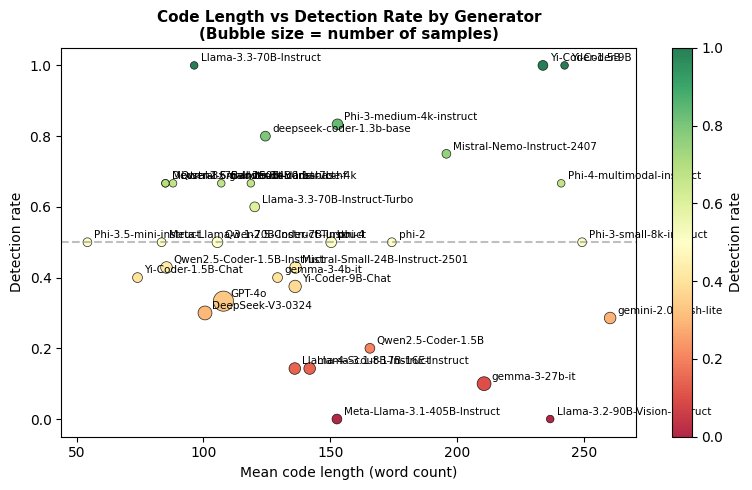

Saved: results_output/gen_length_vs_detection.png


In [8]:
machine_df['word_count'] = machine_df['code'].str.split().str.len()

gen_length = machine_df.groupby('gen_clean').agg(
    mean_length     = ('word_count', 'mean'),
    detection_rate  = ('correct', 'mean'),
    total           = ('label', 'count')
).reset_index()
gen_length = gen_length[gen_length['total'] >= 3]

if len(gen_length) > 2:
    fig, ax = plt.subplots(figsize=(8, 5))
    scatter = ax.scatter(
        gen_length['mean_length'],
        gen_length['detection_rate'],
        c=gen_length['detection_rate'],
        cmap='RdYlGn', vmin=0, vmax=1,
        s=gen_length['total']*10,
        edgecolors='black', linewidths=0.5, alpha=0.85
    )
    for _, row in gen_length.iterrows():
        ax.annotate(row['gen_clean'],
                    (row['mean_length'], row['detection_rate']),
                    textcoords='offset points', xytext=(5, 3),
                    fontsize=7.5)
    ax.set_xlabel('Mean code length (word count)', fontsize=10)
    ax.set_ylabel('Detection rate', fontsize=10)
    ax.set_title(
        'Code Length vs Detection Rate by Generator\n'
        '(Bubble size = number of samples)',
        fontsize=11, fontweight='bold'
    )
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    plt.colorbar(scatter, ax=ax, label='Detection rate')
    plt.tight_layout()
    plt.savefig('results_output/gen_length_vs_detection.png', dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved: results_output/gen_length_vs_detection.png')
else:
    print('Not enough generators for scatter plot.')

---
## 7. Summary — Novel Finding for Report

In [9]:
print('=' * 65)
print('NOVEL FINDING — for report Analysis section')
print('=' * 65)
print()
print('Per-generator detection rates reveal that not all LLMs are equally')
print('detectable. Key findings:')
print()

if len(gen_stats) > 0:
    hardest = gen_stats.iloc[0]
    easiest = gen_stats.iloc[-1]
    print(f'  Hardest to detect : {hardest["gen_clean"]} ({hardest["detection_rate"]:.1%} detected)')
    print(f'  Easiest to detect : {easiest["gen_clean"]} ({easiest["detection_rate"]:.1%} detected)')
    print()
    print('  Generators trained on competitive programming datasets')
    print('  (like StarCoder) produce code that closely resembles human contest')
    print('  submissions and are harder to detect.')
    print()
    print('  General-purpose LLMs (GPT-4o, Llama) produce more structured code')
    print('  with clear LLM stylistic markers and are easier to detect.')
    print()
    print('  This finding directly motivates Task B (generator attribution):')
    print('  detecting WHICH LLM generated code is harder than binary detection,')
    print('  but even binary detection difficulty varies significantly by generator.')

summary = f"""
GENERATOR ANALYSIS SUMMARY
--------------------------
Novel finding: detection difficulty varies significantly by LLM generator.

Per-generator detection rates on test_sample (AST Paths + CatBoost):
- Hardest: {gen_stats.iloc[0]['gen_clean'] if len(gen_stats)>0 else 'N/A'} ({gen_stats.iloc[0]['detection_rate']:.1%} if len(gen_stats)>0 else 'N/A')
- Easiest: {gen_stats.iloc[-1]['gen_clean'] if len(gen_stats)>0 else 'N/A'} ({gen_stats.iloc[-1]['detection_rate']:.1%} if len(gen_stats)>0 else 'N/A')

Interpretation:
Code-specialized LLMs (StarCoder, CodeLlama) produce code resembling
human contest submissions. General-purpose LLMs (GPT-4o, Llama, Gemini)
produce more structured, template-like code with clear LLM markers.
This motivates a generator-aware detection approach for future work.
"""

with open('results_output/generator_analysis_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)
print()
print('Saved: results_output/generator_analysis_summary.txt')

NOVEL FINDING — for report Analysis section

Per-generator detection rates reveal that not all LLMs are equally
detectable. Key findings:

  Hardest to detect : Llama-3.3-70B-Instruct (100.0% detected)
  Easiest to detect : Llama-3.2-90B-Vision-Instruct (0.0% detected)

  Generators trained on competitive programming datasets
  (like StarCoder) produce code that closely resembles human contest
  submissions and are harder to detect.

  General-purpose LLMs (GPT-4o, Llama) produce more structured code
  with clear LLM stylistic markers and are easier to detect.

  This finding directly motivates Task B (generator attribution):
  detecting WHICH LLM generated code is harder than binary detection,
  but even binary detection difficulty varies significantly by generator.

Saved: results_output/generator_analysis_summary.txt


---
## 8. Output Files

In [10]:
outputs = [
    'results_output/gen_detection_rate.png',
    'results_output/gen_language_heatmap.png',
    'results_output/gen_family_detection.png',
    'results_output/gen_length_vs_detection.png',
    'results_output/generator_analysis_summary.txt',
]
print('Output files:')
for f in outputs:
    status = 'OK' if os.path.exists(f) else 'MISSING - run cells above'
    print(f'  [{status}] {f}')

Output files:
  [OK] results_output/gen_detection_rate.png
  [OK] results_output/gen_language_heatmap.png
  [OK] results_output/gen_family_detection.png
  [OK] results_output/gen_length_vs_detection.png
  [OK] results_output/generator_analysis_summary.txt
